In [76]:
!pip install transformers datasets evaluate accelerate torch scikit-learn pandas openpyxl

In [77]:
import pandas as pd
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer, pipeline
from datasets import Dataset, DatasetDict
from google.colab import drive
import numpy as np
import evaluate
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils import resample
import re

In [78]:
import transformers
transformers.logging.disable_progress_bar()

In [79]:
drive.mount('/content/drive')

path = '/content/drive/MyDrive/SentimenAnalisis/dataset_augmented_v2.xlsx'

df = pd.read_excel(path)
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Video_ID,Author,Komentar,sentiment
0,oM9v6P41tRA,@user-yb2mh5ps9t,"kalo dengan budget yg sama, mending beli seri ...",0
1,oM9v6P41tRA,@hadidfaithmuhammad7004,"Btw bang, aku user POCO M7 PRO 5G dan udah ada...",0
2,oM9v6P41tRA,@Toritori-b4s,Bang david gimana setelah nyoba pakai x8 proma...,0
3,oM9v6P41tRA,@SammyEriksoon_Game,S itu SUNAT ya hahahahaha,0
4,oM9v6P41tRA,@ceritaShakeel,dibuat apa dirakit?? wkwkwkwk,0


In [80]:
df = df.dropna(subset=['sentiment'])

df['sentiment'] = df['sentiment'].astype(int)

In [81]:
kamus_alay = {
    "bgtttttttttttttttt": "banget", "bgt": "banget",
    "seksiiiiiiiii": "seksi", "bagussss": "bagus",
    "kerennn": "keren", "jelekkk": "jelek",
    "gak": "tidak", "ga": "tidak", "udh": "sudah"
}

def bersihkan_teks(teks):
    teks = str(teks).lower()

    for alay, baku in kamus_alay.items():
        teks = re.sub(r'\b' + alay + r'\b', baku, teks)

    teks = re.sub(r'(.)\1+', r'\1\1', teks)

    teks = re.sub(r'([!?])\1+', r'\1', teks)

    return teks.strip()

df['clean_comment'] = df['Komentar'].apply(bersihkan_teks)

In [82]:
df = df[['clean_comment', 'sentiment']]

df_netral = df[df['sentiment'] == 0]
df_positif = df[df['sentiment'] == 1]
df_negatif = df[df['sentiment'] == 2]

max_size = max(len(df_netral), len(df_positif), len(df_negatif))

df_positif_upsampled = resample(df_positif, replace=True, n_samples=max_size, random_state=42)
df_negatif_upsampled = resample(df_negatif, replace=True, n_samples=max_size, random_state=42)
df_netral_upsampled = resample(df_netral, replace=True, n_samples=max_size, random_state=42)

df_seimbang = pd.concat([df_netral_upsampled, df_positif_upsampled, df_negatif_upsampled])

train_df, test_df = train_test_split(df_seimbang, test_size=0.2, random_state=42)

train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)

dataset = DatasetDict({
    'train': train_dataset,
    'test': test_dataset
})

model_checkpoint = "indobenchmark/indobert-base-p1"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

def tokenize_function(examples):
  return tokenizer(examples['clean_comment'], padding= 'max_length', truncation=True, max_length=128)

tokenized_datasets = dataset.map(tokenize_function, batched=True)

tokenized_datasets = tokenized_datasets.remove_columns(['clean_comment', '__index_level_0__'])
tokenized_datasets = tokenized_datasets.rename_column('sentiment', 'labels')
tokenized_datasets.set_format('torch')

print(tokenized_datasets)

Map:   0%|          | 0/1204 [00:00<?, ? examples/s]

Map:   0%|          | 0/302 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1204
    })
    test: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 302
    })
})


In [83]:
id2label = {0: "Netral", 1: "Positif", 2: "Negatif"}
label2id = {"Netral": 0, "Positif": 1, "Negatif": 2}

model = AutoModelForSequenceClassification.from_pretrained(
    model_checkpoint,
    num_labels=3,
    id2label=id2label,
    label2id=label2id
)

metric_acc = evaluate.load("accuracy")
metric_f1 = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    accuracy = metric_acc.compute(predictions=predictions, references=labels)["accuracy"]
    f1 = metric_f1.compute(predictions=predictions, references=labels, average="macro")["f1"]

    return {"accuracy": accuracy, "f1_macro": f1}

training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=3e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=8,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["test"],
    compute_metrics=compute_metrics,
)

print("Memulai proses Fine-Tuning IndoBERT")
trainer.train()

BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Memulai proses Fine-Tuning IndoBERT


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,No log,0.526648,0.774834,0.778068
2,No log,0.176547,0.943709,0.943808
3,No log,0.340524,0.927152,0.926506
4,No log,0.219125,0.953642,0.953386
5,No log,0.251020,0.960265,0.960176
6,No log,0.281480,0.950331,0.950088
7,0.158816,0.277823,0.950331,0.950088
8,0.158816,0.278152,0.950331,0.950021


There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=608, training_loss=0.13107060802806364, metrics={'train_runtime': 686.0241, 'train_samples_per_second': 14.04, 'train_steps_per_second': 0.886, 'total_flos': 633577109889024.0, 'train_loss': 0.13107060802806364, 'epoch': 8.0})

In [84]:
output_prediksi = trainer.predict(tokenized_datasets["test"])

tebakan_indobert = np.argmax(output_prediksi.predictions, axis=-1)
label_asli = output_prediksi.label_ids

print("HASIL EVALUASI INDOBERT")
print(classification_report(label_asli, tebakan_indobert, target_names=["Netral (0)", "Positif (1)", "Negatif (2)"]))

HASIL EVALUASI INDOBERT
              precision    recall  f1-score   support

  Netral (0)       0.94      0.91      0.92       100
 Positif (1)       0.98      0.97      0.97       100
 Negatif (2)       0.92      0.95      0.93       102

    accuracy                           0.94       302
   macro avg       0.94      0.94      0.94       302
weighted avg       0.94      0.94      0.94       302



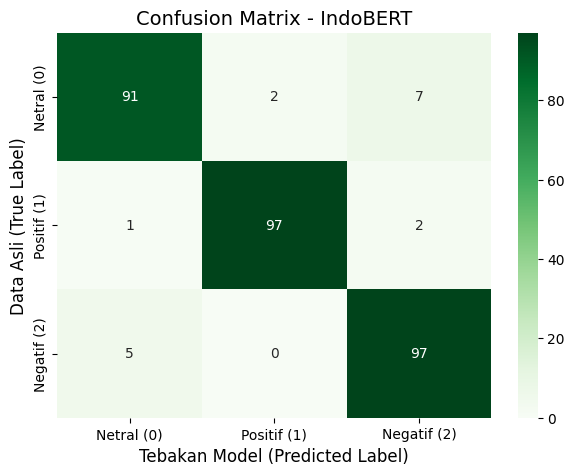

In [85]:
cm_bert = confusion_matrix(label_asli, tebakan_indobert)
label_names = ['Netral (0)', 'Positif (1)', 'Negatif (2)']

plt.figure(figsize=(7, 5))
sns.heatmap(cm_bert, annot=True, fmt='d', cmap='Greens',
            xticklabels=label_names,
            yticklabels=label_names)
plt.title('Confusion Matrix - IndoBERT', fontsize=14)
plt.xlabel('Tebakan Model (Predicted Label)', fontsize=12)
plt.ylabel('Data Asli (True Label)', fontsize=12)
plt.show()

In [93]:
nlp_pipeline = pipeline("text-classification", model=model, tokenizer=tokenizer, device=0)

def tebak_sentimen_bert(kalimat):
    hasil = nlp_pipeline(kalimat)[0]
    label = hasil['label']
    score = hasil['score']

    print(f"Komentar: '{kalimat}'")
    print(f"Tebakan IndoBERT: {label} (Tingkat Keyakinan: {score * 100:.2f}%)")
    print("-" * 40)

tebak_sentimen_bert("Wah mantap banget hpnya, baru 5 menit langsung panas")
tebak_sentimen_bert("kamera bagus, tapi baterainya jelek banget anjir")
tebak_sentimen_bert("coba main mobile legend pakai j2 prime bang")
tebak_sentimen_bert('Performanya stabil, multitasking aman')
tebak_sentimen_bert("Keren banget kameranya, muka saya jadi kayak CCTV 2007")
tebak_sentimen_bert('Terbaik lah hp ini')
tebak_sentimen_bert("Najis punya hp kek gini")
tebak_sentimen_bert("Update terbaru ini sangat membantu, sekarang aplikasinya malah gak bisa dibuka.")
tebak_sentimen_bert("Gaming phone terbaik, buka game aja patah-patah.")
tebak_sentimen_bert("Speaker-nya ternyata nendang juga.")
tebak_sentimen_bert("Battery awet banget, dipakai seharian masih sisa.")
tebak_sentimen_bert('keren banget')
tebak_sentimen_bert('suka si iphone yang kuning ini')

Komentar: 'Wah mantap banget hpnya, baru 5 menit langsung panas'
Tebakan IndoBERT: Negatif (Tingkat Keyakinan: 99.01%)
----------------------------------------
Komentar: 'kamera bagus, tapi baterainya jelek banget anjir'
Tebakan IndoBERT: Negatif (Tingkat Keyakinan: 95.12%)
----------------------------------------
Komentar: 'coba main mobile legend pakai j2 prime bang'
Tebakan IndoBERT: Netral (Tingkat Keyakinan: 99.65%)
----------------------------------------
Komentar: 'Performanya stabil, multitasking aman'
Tebakan IndoBERT: Positif (Tingkat Keyakinan: 98.67%)
----------------------------------------
Komentar: 'Keren banget kameranya, muka saya jadi kayak CCTV 2007'
Tebakan IndoBERT: Negatif (Tingkat Keyakinan: 96.95%)
----------------------------------------
Komentar: 'Terbaik lah hp ini'
Tebakan IndoBERT: Negatif (Tingkat Keyakinan: 92.02%)
----------------------------------------
Komentar: 'Najis punya hp kek gini'
Tebakan IndoBERT: Netral (Tingkat Keyakinan: 51.21%)
------------

In [87]:
model.save_pretrained("./model_indobert_final")
tokenizer.save_pretrained("./model_indobert_final")

('./model_indobert_final/tokenizer_config.json',
 './model_indobert_final/tokenizer.json')

In [88]:
!zip -r model_indobert_final.zip ./model_indobert_final

updating: model_indobert_final/ (stored 0%)
updating: model_indobert_final/tokenizer_config.json (deflated 42%)
updating: model_indobert_final/model.safetensors (deflated 7%)
updating: model_indobert_final/config.json (deflated 57%)
updating: model_indobert_final/tokenizer.json (deflated 71%)
